In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('creditcard.csv')
df = df.drop_duplicates()
df.shape

(283726, 31)

In [7]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

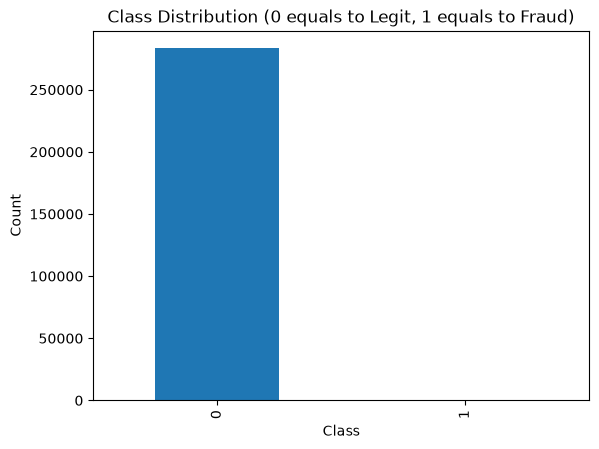

In [8]:
df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution (0 equals to Legit, 1 equals to Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

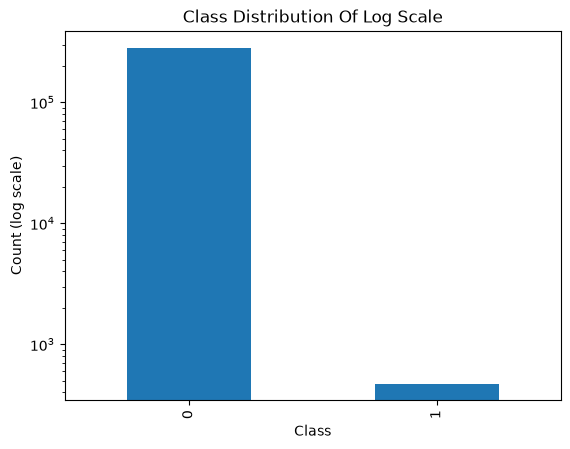

In [9]:
df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution Of Log Scale')
plt.xlabel('Class')
plt.ylabel('Count (log scale)')
plt.yscale('log')
plt.show()

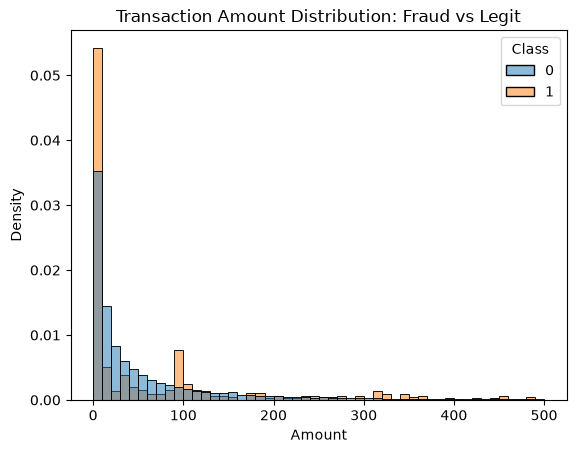

In [10]:
sns.histplot(data=df, x='Amount', hue='Class', stat='density', common_norm=False, bins=50, binrange=(0, 500))
plt.title('Transaction Amount Distribution: Fraud vs Legit')
plt.xlabel('Amount')
plt.show()

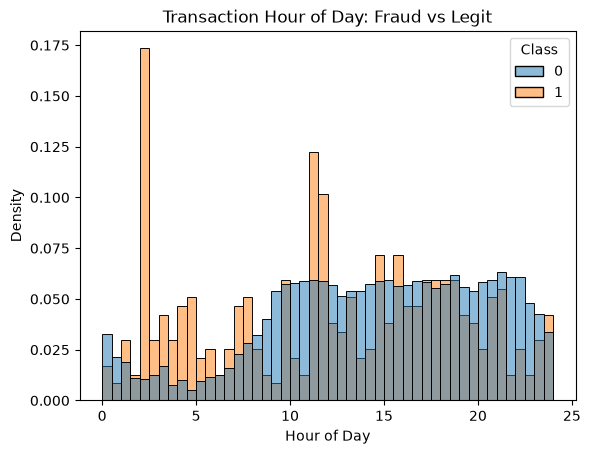

In [11]:
df['Hour'] = (df['Time'] % 86400) / 3600
sns.histplot(data=df, x='Hour', hue='Class', stat='density', common_norm=False, bins=48)
plt.title('Transaction Hour of Day: Fraud vs Legit')
plt.xlabel('Hour of Day')
plt.show()

In [12]:
correlations = df.corr()['Class'].sort_values()
print(correlations)

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Hour     -0.016696
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64


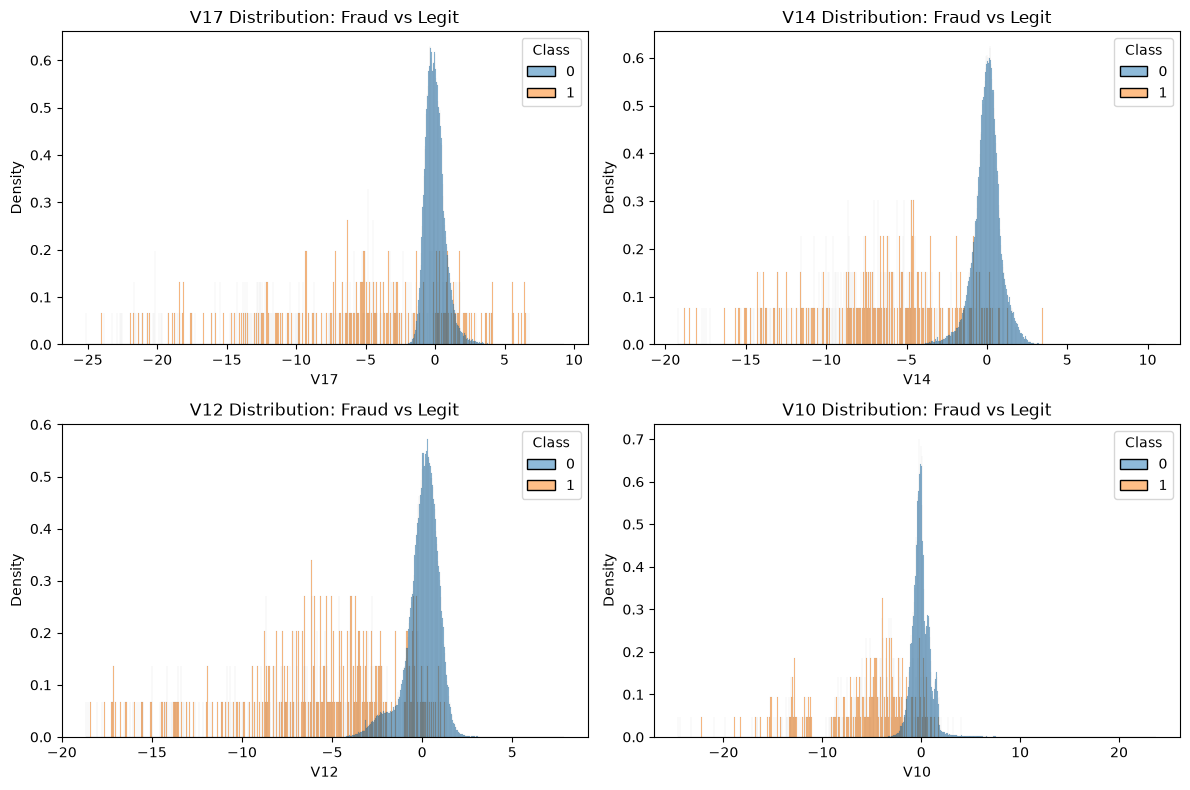

In [13]:
top_features = ['V17', 'V14', 'V12', 'V10']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.histplot(data=df, x=feature, hue='Class', stat='density', common_norm=False, ax=axes[i])
    axes[i].set_title(f'{feature} Distribution: Fraud vs Legit')

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(y_train.value_counts())
print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_baseline = LogisticRegression(max_iter=1000)
model_baseline.fit(X_train, y_train)

y_pred_baseline = model_baseline.predict(X_test)

print(confusion_matrix(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

[[56643     8]
 [   36    59]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.62      0.73        95

    accuracy                           1.00     56746
   macro avg       0.94      0.81      0.86     56746
weighted avg       1.00      1.00      1.00     56746



c:\Users\Datachroma\Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
model_baseline_scaled = LogisticRegression(max_iter=1000)
model_baseline_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_baseline_scaled.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

[[56641    10]
 [   39    56]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [18]:
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced')
model_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = model_weighted.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_weighted))
print(classification_report(y_test, y_pred_weighted))

[[55237  1414]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746



In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


In [20]:
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

[[55124  1527]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



In [21]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[56648     3]
 [   27    68]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [22]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[56648     3]
 [   27    68]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

